Importing Required Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os ,warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')

Observation:Libraries imported successfully 

Load the dataset 

In [2]:
import pandas as pd
df = pd.read_csv("retail_sales_dataset (2).csv")

Observation:Successfully loaded the dataset 

Inspect the dataset 

In [3]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

    


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


np.int64(0)

Observation 

dataset has 1000 entries 9 columns it provides the needed data for customer-level RFM-analysis 

Prepare Invoice Date

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv('retail_sales_dataset (2).csv')
print(df.columns.tolist())  
print(df.shape)

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']
(1000, 9)


Observation 

The file has 200k customers with 19 features.InvoiceDate is missing,it is a customer Segmentatin dataset,not E-Commerce sales data.

Create RFM table 

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
reference_date = df["Date"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg(
    Recency=("Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Date", "count"),
    Monetary=("Total Amount", "sum")
).reset_index()
print(rfm.head())

  Customer ID  Recency  Frequency  Monetary
0     CUST001       39          1       150
1     CUST002      309          1      1000
2     CUST003      354          1        30
3     CUST004      226          1       500
4     CUST005      241          1       100


observation: RFM table created successfully based on Customer ID with Recency, Frequency and Monetary values.

descriptive statistics

In [6]:
print("Average Purchase Value:", df["Total Amount"].mean())
print("Average Purchase Frequency:", rfm["Frequency"].mean())
print("Average customer Monetary Value:", rfm["Monetary"].mean())
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Average Purchase Value: 456.0
Average Purchase Frequency: 1.0
Average customer Monetary Value: 456.0


Check RFM Distribution 

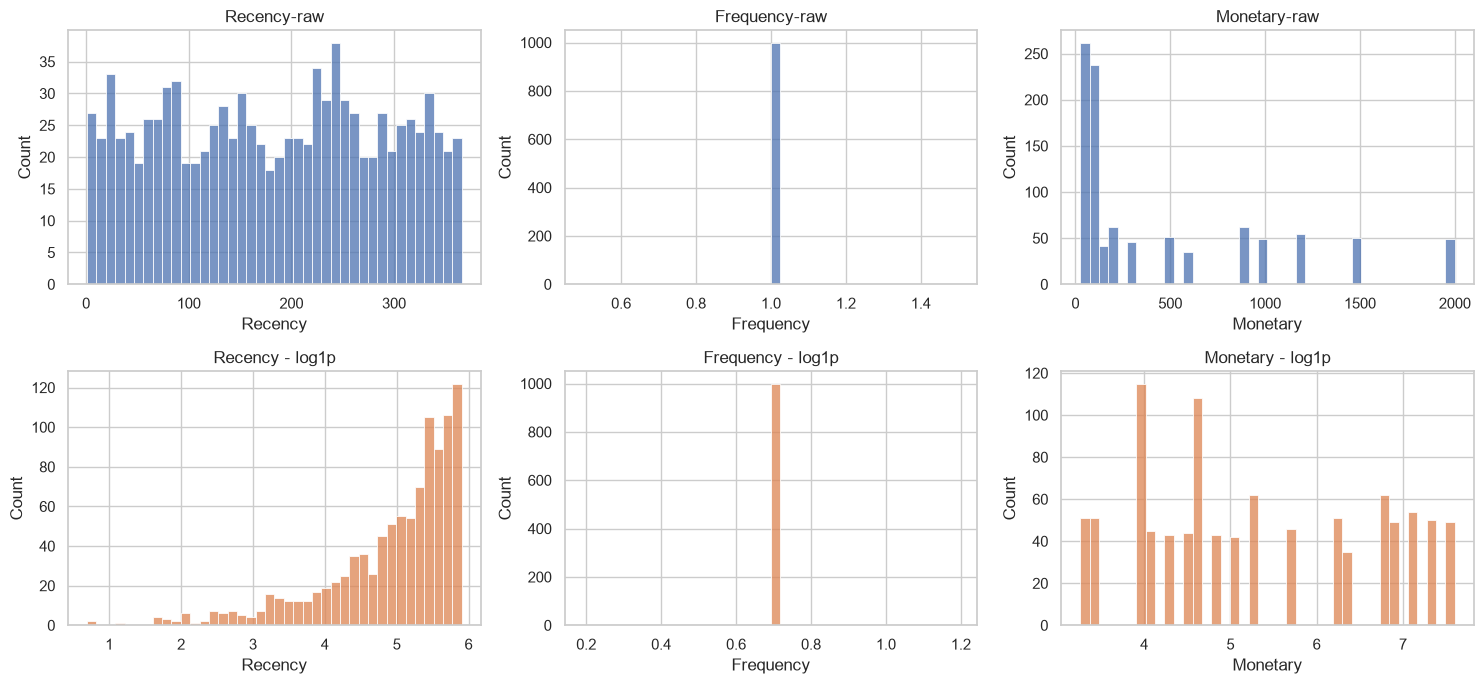

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
fig, axes = plt.subplots(2,3, figsize=(15,7))
for i, col in enumerate(["Recency","Frequency","Monetary"]):
    sns.histplot(rfm[col], bins=40, ax=axes[0,i], color="#4C72b0")
    axes[0, i].set_title(f"{col}-raw")
    sns.histplot(np.log1p(rfm[col]), bins=40, ax=axes[1,i], color="#DD8452")
    axes[1,i].set_title(f"{col} - log1p")
plt.tight_layout(); plt.show()

Observation 

Recency is spread almost uniformly (0-360 days),Frequency is 1 for almost all customers,and Monetary is highly skewed to the left.After log1p transformation,Monetary distribution because more balanced and suitable for clustering.

standardisation

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print("Mean after scaling:", np.round(X.mean(axis=0), 3))
print("Std after scaling:", np.round(X.std(axis=0), 3))
pd.DataFrame(X, columns=["R","F","M"]).describe().round(2)

Mean after scaling: [ 0. -0. -0.]
Std after scaling: [1. 0. 1.]


,R,F,M
count,1000.00,1000.0,1000.00
mean,0.00,-0.0,-0.00
std,1.00,0.0,1.00
min,-4.60,-0.0,-1.52
25%,-0.46,-0.0,-0.88
50%,0.33,-0.0,-0.29
75%,0.73,-0.0,1.13
max,1.06,-0.0,1.72


K-means and the elbow method

  Customer ID  Recency  Frequency  Monetary
0     CUST001       39          1       150
1     CUST002      309          1      1000
2     CUST003      354          1        30
3     CUST004      226          1       500
4     CUST005      241          1       100
Average Purchase Value: 456.0
Average Purchase Frequency: 1.0
Average Monetary Value: 456.0


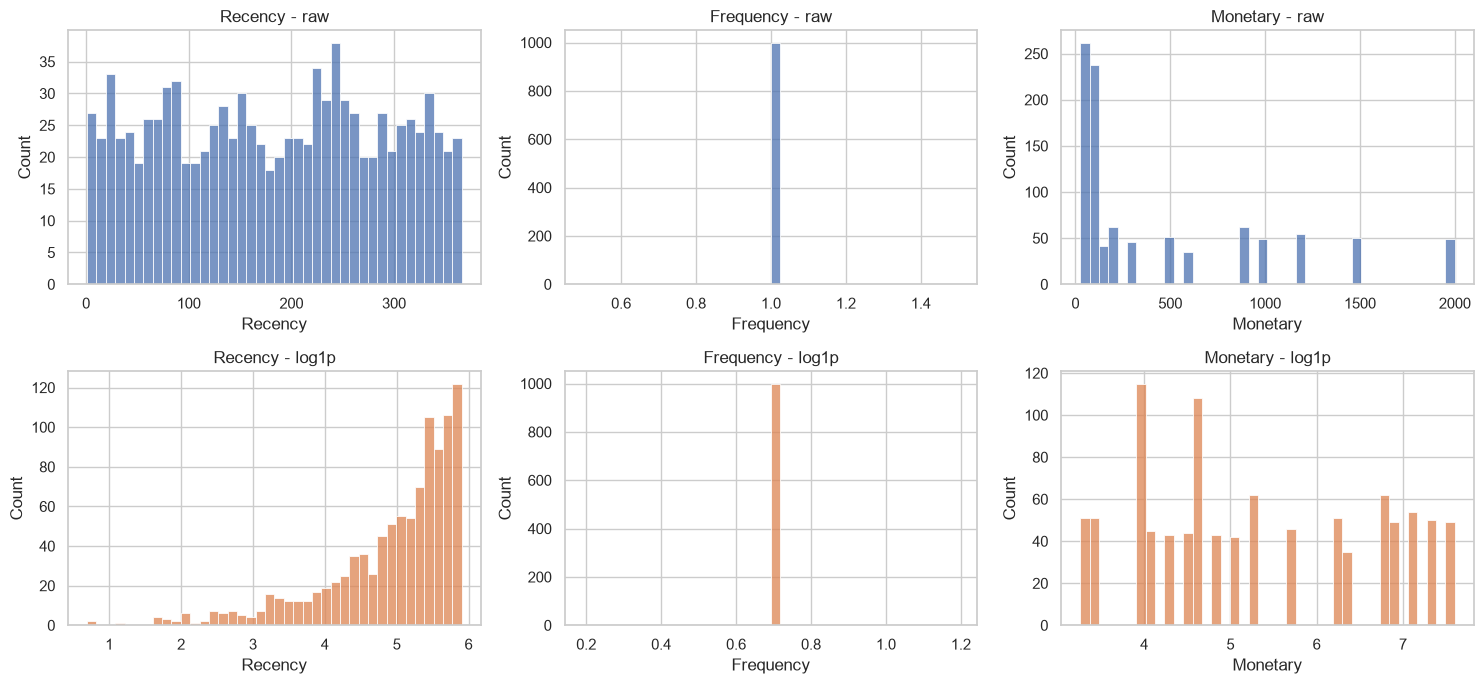

Mean after scaling: [ 0. -0. -0.]
Std after scaling: [1. 0. 1.]


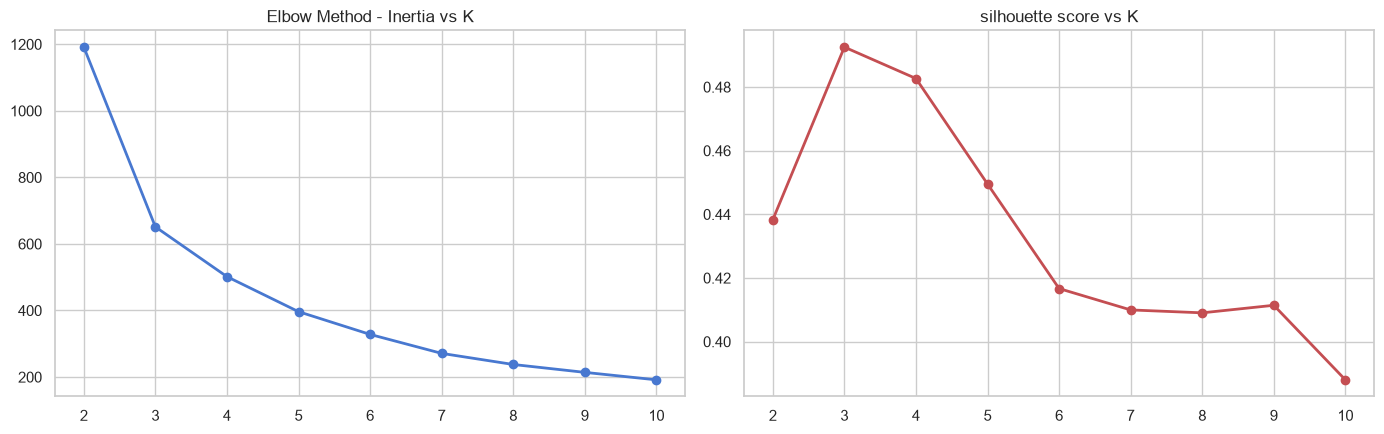

K=2 inertia=   1191.5 silhouette=0.438
K=3 inertia=    651.3 silhouette=0.493
K=4 inertia=    501.6 silhouette=0.483
K=5 inertia=    396.4 silhouette=0.450
K=6 inertia=    328.1 silhouette=0.417
K=7 inertia=    271.1 silhouette=0.410
K=8 inertia=    237.7 silhouette=0.409
K=9 inertia=    214.0 silhouette=0.411
K=10 inertia=    191.6 silhouette=0.388
silhouette score at K=4: 0.48
Cluster
0    306
1    160
2     87
3    447
Name: count, dtype: int64
  Customer ID  Recency  Frequency  Monetary  Cluster
0     CUST001       39          1       150        1
1     CUST002      309          1      1000        0
2     CUST003      354          1        30        3
3     CUST004      226          1       500        0
4     CUST005      241          1       100        3


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df["Date"] = pd.to_datetime(df["Date"])
reference_date = df["Date"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg(
    Recency=("Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Date", "count"),
    Monetary=("Total Amount", "sum")
).reset_index()
print(rfm.head())
print("Average Purchase Value:", df["Total Amount"].mean())
print("Average Purchase Frequency:", rfm["Frequency"].mean())
print("Average Monetary Value:", rfm["Monetary"].mean())
fig, axes = plt.subplots(2,3, figsize=(15,7))
for i, col in enumerate(["Recency","Frequency","Monetary"]):
    sns.histplot(rfm[col], bins=40, ax=axes[0,i], color="#4C72b0")
    axes[0,i].set_title(f"{col} - raw")
    sns.histplot(np.log1p(rfm[col]), bins=40, ax=axes[1,i], color="#DD8452")
    axes[1,i].set_title(f"{col} - log1p")
plt.tight_layout(); plt.show()
rfm_log = np.log1p(rfm[["Recency","Frequency","Monetary"]])
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print("Mean after scaling:", np.round(X.mean(axis=0), 3))
print("Std after scaling:", np.round(X.std(axis=0), 3))
RANDOM_STATE = 42
k_range = range(2, 11)
inertia, sil = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(k_range), inertia, marker='o', lw=2)
axes[0].set_title("Elbow Method - Inertia vs K")
axes[1].plot(list(k_range), sil, marker='o', lw=2, color="#C44E52")
axes[1].set_title("silhouette score vs K")
plt.tight_layout(); plt.show()
for k,i,s in zip(k_range, inertia, sil):
    print(f"K={k} inertia={i:9.1f} silhouette={s:.3f}")
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)

print("silhouette score at K=4:", round(silhouette_score(X, rfm["Cluster"]),2))
print(rfm["Cluster"].value_counts().sort_index())
print(rfm.head())

Visualizing the clusters

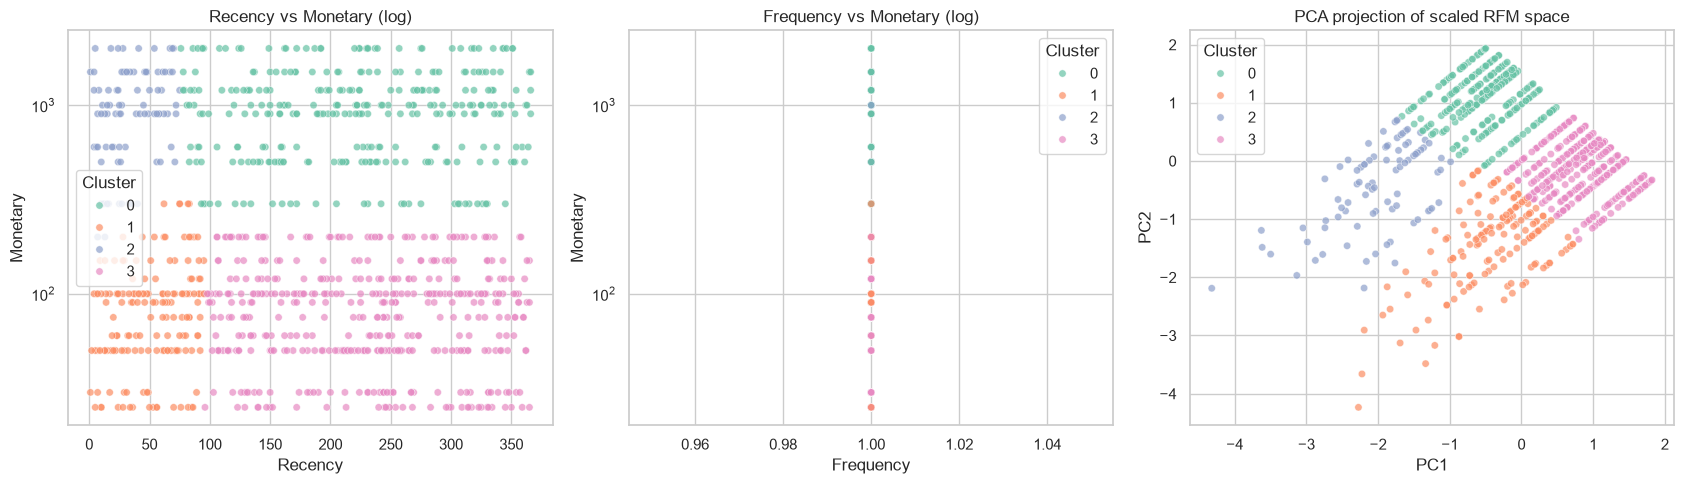

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pal = "Set2"
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette=pal, alpha=.7, s=28, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Recency vs Monetary (log)")
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette=pal, alpha=.7, s=28, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Frequency vs Monetary (log)")
pcs = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=rfm["Cluster"], palette=pal, alpha=.7, s=28, ax=axes[2])
axes[2].set_title("PCA projection of scaled RFM space")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
plt.tight_layout()
plt.show()

observation 
The plots show clear separation between customer groups, confirming that K-Means has successfully created meaningful customer segments.

cluster profiling

In [11]:
profile = rfm.groupby("Cluster").agg(
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    Monetary_total=("Monetary", "sum"),
    Customers=("Customer ID", "count")
)
profile["% of customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["% of revenue"] = (profile["Monetary_total"] / profile["Monetary_total"].sum() * 100).round(1)
r_rank = profile["Recency_mean"].rank()
f_rank = profile["Frequency_mean"].rank(ascending=False)
m_rank = profile["Monetary_mean"].rank(ascending=False)
score = r_rank + f_rank + m_rank
order = score.sort_values().index
names = ["Champions", "Loyal Customers", "Occasional Buyers", "At-Risk / Hibernating"]
name_map = {cl: nm for cl, nm in zip(order, names[:len(order)])}
profile["Segment"] = [name_map[c] for c in profile.index]
rfm["Segment"] = rfm["Cluster"].map(name_map)
profile[["Segment", "Recency_mean", "Frequency_mean", "Monetary_mean", "Customers", "% of customers", "% of revenue"]]

,Segment,Recency_mean,Frequency_mean,Monetary_mean,Customers,% of customers,% of revenue
Cluster,,,,,,,
0,Loyal Customers,223.310458,1.0,1022.222222,306,30.6,68.6
1,Occasional Buyers,51.537500,1.0,90.437500,160,16.0,3.2
2,Champions,34.735632,1.0,1022.988506,87,8.7,19.5
3,At-Risk / Hibernating,231.277405,1.0,88.881432,447,44.7,8.7


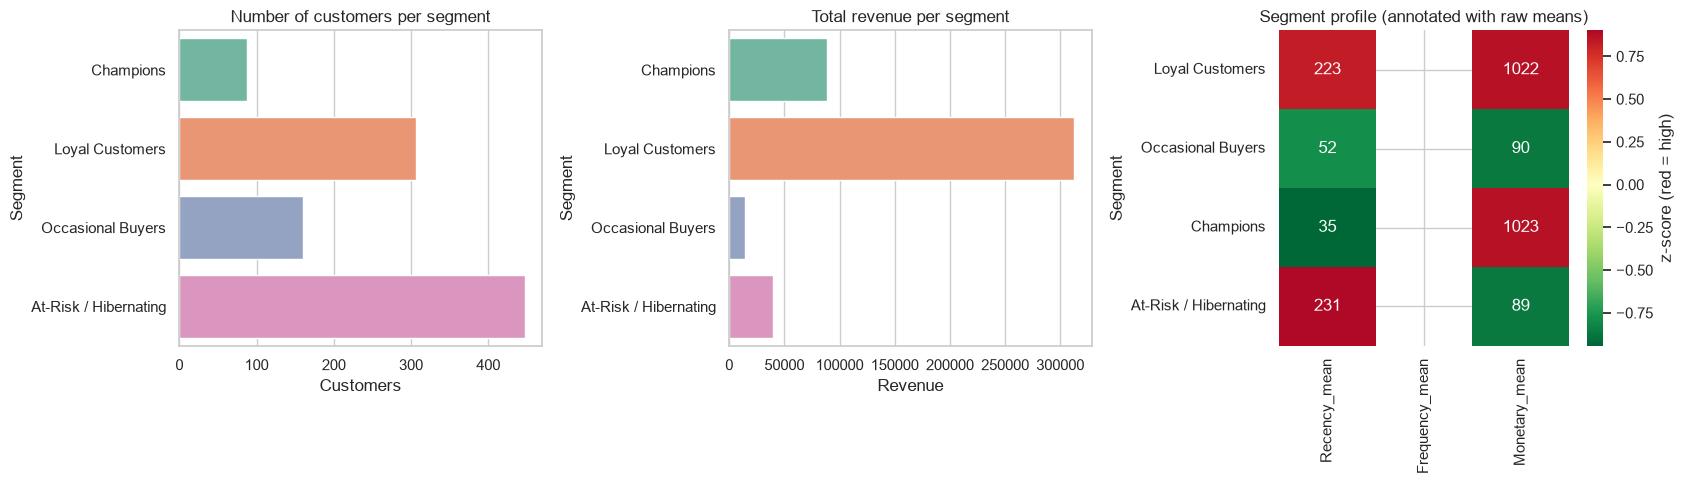

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
df = pd.read_csv("retail_sales_dataset (2).csv")
df["Date"] = pd.to_datetime(df["Date"])
ref_date = df["Date"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg(
    Recency=("Date", lambda x: (ref_date - x.max()).days),
    Frequency=("Date", "count"),
    Monetary=("Total Amount", "sum")
).reset_index()
X = StandardScaler().fit_transform(np.log1p(rfm[["Recency","Frequency","Monetary"]]))
rfm["Cluster"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)
profile = rfm.groupby("Cluster").agg(
    Recency_mean=("Recency","mean"), Frequency_mean=("Frequency","mean"),
    Monetary_mean=("Monetary","mean"), Monetary_total=("Monetary","sum"),
    Customers=("Customer ID","count")
)
score = profile["Recency_mean"].rank() + profile["Frequency_mean"].rank(ascending=False) + profile["Monetary_mean"].rank(ascending=False)
names = ["Champions", "Loyal Customers", "Occasional Buyers", "At-Risk / Hibernating"]
name_map = {cl: nm for cl, nm in zip(score.sort_values().index, names)}
profile["Segment"] = profile.index.map(name_map)
rfm["Segment"] = rfm["Cluster"].map(name_map)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
counts = rfm["Segment"].value_counts().reindex(names).dropna()
sns.barplot(x=counts.values, y=counts.index, ax=axes[0], palette="Set2")
axes[0].set_title("Number of customers per segment"); axes[0].set_xlabel("Customers")
rev = rfm.groupby("Segment")["Monetary"].sum().reindex(counts.index)
sns.barplot(x=rev.values, y=rev.index, ax=axes[1], palette="Set2")
axes[1].set_title("Total revenue per segment"); axes[1].set_xlabel("Revenue")
heat = profile.set_index("Segment")[["Recency_mean", "Frequency_mean", "Monetary_mean"]]
heat_z = (heat - heat.mean()) / heat.std()
sns.heatmap(heat_z, annot=heat.round(0), fmt=".0f", cmap="RdYlGn_r", center=0, ax=axes[2], cbar_kws={"label": "z-score (red = high)"})
axes[2].set_title("Segment profile (annotated with raw means)")
plt.tight_layout(); plt.show()

observation:

Customer segmentation clearly divides customers into different value groups. At-Risk customers are highest in number, while Loyal Customers bring the most revenue. This helps the business to create targeted marketing strategies instead of using one strategy for all.

- Champions (Recent, frequent, high-value): Give VIP offers, exclusive products, early access.
- Loyal Customers (Regular buyers): Use loyalty points and personalized offers to increase spending.
- Occasional Buyers / Potential Loyalists: Encourage more purchases with personalized recommendations and limited-time offers.
- At-Risk / Hibernating (Old valuable customers): Send win-back discounts and reminders.
- Lost Customers (Low recency & low engagement): Try reactivation campaigns, stop spending if no response.
- New Customers: Give welcome offers and second-purchase incentives.

